In [1]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

df = pd.read_csv("../data/vulkg/VulnerabilityNodes_clean.csv")
df

,cveID,publishedDate,description_value,num_reference,v2version,v2baseScore,v2accessVector,v2accessComplexity,v2authentication,v2confidentialityImpact,...,v3privilegesRequired,v3userInteraction,v3scope,v3confidentialityImpact,v3integrityImpact,v3availabilityImpact,v3vectorString,v3impactScore,v3exploitabilityScore,v3baseSeverity
0,CVE-1999-0095,1988-10-01,NaN,0,2,10.0,NETWORK,LOW,NONE,COMPLETE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
1,CVE-1999-0082,1988-11-11,NaN,0,2,10.0,NETWORK,LOW,NONE,COMPLETE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
2,CVE-1999-1471,1989-01-01,NaN,0,2,7.2,LOCAL,LOW,NONE,COMPLETE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
3,CVE-1999-1122,1989-07-26,NaN,0,2,4.6,LOCAL,LOW,NONE,PARTIAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
4,CVE-1999-1467,1989-10-26,NaN,0,2,10.0,NETWORK,LOW,NONE,COMPLETE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324613,CVE-2025-59709,2026-04-03,NaN,0,0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
324614,CVE-2025-59710,2026-04-03,NaN,0,0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
324615,CVE-2025-59711,2026-04-03,NaN,0,0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN
324616,CVE-2026-26477,2026-04-03,NaN,0,0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN


In [2]:
cve_cnts = Counter(df["cveID"].apply(lambda x: x[4:8]).tolist())

In [4]:
cve_cnts['2026'] = 29624

In [9]:
sum(cve_cnts.values())

343598

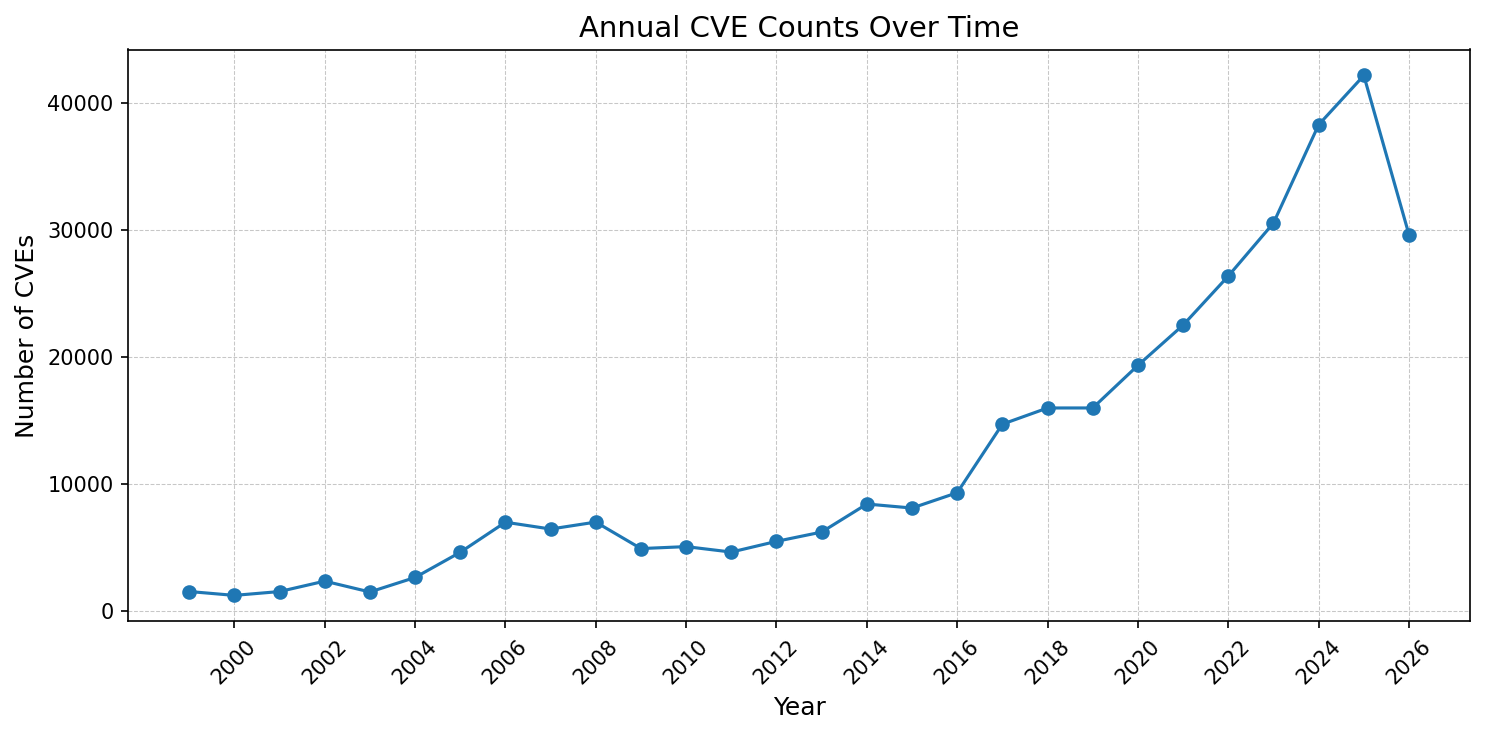

In [6]:
# Sort by year
years = sorted(cve_cnts.keys(), key=int)
counts = [cve_cnts[y] for y in years]

plt.figure(figsize=(10, 5), dpi=150)

# Plot all points
plt.plot(years, counts, marker='o')

plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of CVEs", fontsize=12)
plt.title("Annual CVE Counts Over Time", fontsize=14)

# Show labels only for even years
even_years = [y for y in years if int(y) % 2 == 0]
plt.xticks(even_years, rotation=45)

plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig("cve_trend.png", dpi=300, bbox_inches='tight')
plt.show()

In [17]:
import csv
from pathlib import Path

INPUT_CSV = "D:\\Research\\Research_with_Jiao\\VulGD-Dynamic-Database\\VulLink-Data-Pipeline\\datasource\\VulnerabilityNodesAddProperties.csv"
OUTPUT_CSV = "D:\\Research\\Research_with_Jiao\\VulGD-Dynamic-Database\\data\\vulkg\\VulnerabilityNodesAddProperties.csv"

def split_cwe_field(cwe_value: str):
    """
    Split a CWE field like:
      CWE-502
      CWE-320,CWE-321
      "CWE-320,CWE-321"
    into:
      ["CWE-502"]
      ["CWE-320", "CWE-321"]
    """
    if cwe_value is None:
        return [""]

    cwe_value = cwe_value.strip()

    if not cwe_value:
        return [""]

    parts = [p.strip() for p in cwe_value.split(",")]
    parts = [p for p in parts if p]  # remove empty pieces

    return parts if parts else [""]


def main():
    input_path = Path(INPUT_CSV)
    output_path = Path(OUTPUT_CSV)

    with input_path.open("r", encoding="utf-8", newline="") as infile, \
         output_path.open("w", encoding="utf-8", newline="") as outfile:

        reader = csv.DictReader(infile)
        fieldnames = reader.fieldnames

        if not fieldnames:
            raise ValueError("Input CSV has no header row.")

        if "CWEID" not in fieldnames:
            raise ValueError("Input CSV must contain a 'CWEID' column.")

        writer = csv.DictWriter(outfile, fieldnames=fieldnames)
        writer.writeheader()

        total_in = 0
        total_out = 0
        split_rows = 0

        for row in reader:
            total_in += 1
            cwe_values = split_cwe_field(row.get("CWEID", ""))

            if len(cwe_values) > 1:
                split_rows += 1

            for cwe in cwe_values:
                new_row = row.copy()
                new_row["CWEID"] = cwe
                writer.writerow(new_row)
                total_out += 1

    print(f"Done.")
    print(f"Input rows:  {total_in}")
    print(f"Split rows:  {split_rows}")
    print(f"Output rows: {total_out}")
    print(f"Saved to:    {output_path}")


if __name__ == "__main__":
    main()

Done.
Input rows:  318667
Split rows:  25266
Output rows: 346108
Saved to:    D:\Research\Research_with_Jiao\VulGD-Dynamic-Database\data\vulkg\VulnerabilityNodesAddProperties.csv
